In [1]:
pip install torch --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128


In [2]:
!pip -q install -U deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 13.1 MB/s eta 0:00:00


In [3]:
!pip install numpy

In [4]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

import torch
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [5]:
print("CUDA is available:", torch.cuda.is_available())

# Model parameters
r, Nm, n = 0.39, 0.89, 2.5
gu, gL = 0.05, 0.005

a_scale, bu_scale, uth_scale = 1.58, 15.8, 0.7
gLu_scale, bL_scale, uth_e_scale = 0.3, 0.8, 0.75

N0 = 0.0000798
scale_factor = 1e-7

# Reference solution
def get_scipy_solution():
    t_span = (0, 200)
    t_eval = np.linspace(0, 200, 2000)

    y0 = [N0, 0.0, 0.0]

    def rhs(t, y):
        N, u, L = max(y[0], 0), max(y[1], 0), max(y[2], 0)
        dN = r * N * (1 - N / 0.89)
        hill_u = (u**n) / ((7e-8)**n + u**n + 1e-20)
        du = (N / 0.89) * (1.58e-7 + 1.58e-6 * hill_u) - 0.05 * u - 3e6 * u * L
        hill_L = (u**n) / ((7.5e-8)**n + u**n + 1e-20)
        dL = 8e-8 * (N / 0.89) * hill_L - 0.005 * L
        return [dN, du, dL]

    sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval, method='Radau', rtol=1e-8, atol=1e-11)

    interp_N = interp1d(sol.t, sol.y[0], kind='cubic', fill_value="extrapolate")
    interp_U = interp1d(sol.t, sol.y[1] / scale_factor, kind='cubic', fill_value="extrapolate")
    interp_V = interp1d(sol.t, sol.y[2] / scale_factor, kind='cubic', fill_value="extrapolate")

    return interp_N, interp_U, interp_V

interp_N, interp_U, interp_V = get_scipy_solution()

def reference_solution(t):
    t_flat = t.flatten()
    ans = np.vstack((interp_N(t_flat), interp_U(t_flat), interp_V(t_flat))).T
    return ans.astype(np.float32)

CUDA is available: True


In [6]:
# PINN Equations
def ode_system(t, y):
    N, U, V = y[:, 0:1], y[:, 1:2], y[:, 2:3]

    dN_dt = dde.grad.jacobian(y, t, i=0, j=0)
    dU_dt = dde.grad.jacobian(y, t, i=1, j=0)
    dV_dt = dde.grad.jacobian(y, t, i=2, j=0)

    eq1 = dN_dt - r * N * (1.0 - N / Nm)

    U_safe = torch.abs(U) + 1e-8
    hill_u = (U_safe**n) / (uth_scale**n + U_safe**n)
    eq2 = dU_dt - (N / Nm) * (a_scale + bu_scale * hill_u) + gu * U + gLu_scale * U * V

    hill_L = (U_safe**n) / (uth_e_scale**n + U_safe**n)
    eq3 = dV_dt - bL_scale * (N / Nm) * hill_L + gL * V

    return [eq1, eq2, eq3]

geom = dde.geometry.TimeDomain(0, 200.0)

t_anchors = np.linspace(0, 200, 50, dtype=np.float32).reshape(-1, 1)
y_anchors = reference_solution(t_anchors)

anchor_N = dde.icbc.PointSetBC(t_anchors, y_anchors[:, 0:1], component=0)
anchor_U = dde.icbc.PointSetBC(t_anchors, y_anchors[:, 1:2], component=1)
anchor_V = dde.icbc.PointSetBC(t_anchors, y_anchors[:, 2:3], component=2)

data = dde.data.PDE(
    geom,
    ode_system,
    [anchor_N, anchor_U, anchor_V],
    num_domain=2000,
    num_test=1000,
    solution=reference_solution
)

def input_transform(t):
    return t / 200.0

net = dde.nn.FNN([1] + [64] * 5 + [3], "tanh", "Glorot normal")
net.apply_feature_transform(input_transform)

model = dde.Model(data, net)

print("--- 1.1: Adam (lr = 1e-3) ---")
loss_weights = [1, 5, 1, 10, 10, 10]
model.compile("adam", lr=1e-3, loss_weights=loss_weights)
model.train(iterations=20000, display_every=1000)

print("\n--- 1.2: Adam (lr = 1e-4) ---")
model.compile("adam", lr=1e-4, loss_weights=loss_weights)
model.train(iterations=10000, display_every=1000)

print("\n--- 1.3: Adam (lr = 1e-5) ---")
model.compile("adam", lr=1e-5, loss_weights=loss_weights)
model.train(iterations=5000, display_every=1000)

print("\n--- 2: L-BFGS ---")
dde.optimizers.config.set_LBFGS_options(
    maxiter=5000,
)
model.compile("L-BFGS")
model.train()


--- 1.1: Adam (lr = 1e-3) ---
Compiling model...
'compile' took 9.033208 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [2.30e-05, 6.36e-03, 1.49e-07, 7.01e+00, 1.40e+02, 1.15e+04]    [2.30e-05, 6.37e-03, 1.49e-07, 7.01e+00, 1.40e+02, 1.15e+04]    []  
1000      [9.82e-04, 5.64e-02, 1.64e-02, 6.19e-02, 8.84e+00, 5.75e+01]    [9.86e-04, 5.67e-02, 1.64e-02, 6.19e-02, 8.84e+00, 5.75e+01]    []  
2000      [3.99e-04, 3.33e-02, 5.36e-03, 1.08e-02, 9.94e-01, 5.22e+01]    [3.97e-04, 3.30e-02, 5.37e-03, 1.08e-02, 9.94e-01, 5.22e+01]    []  
3000      [5.34e-04, 4.06e-02, 7.60e-03, 2.68e-02, 3.37e-01, 5.23e-01]    [5.35e-04, 4.08e-02, 7.62e-03, 2.68e-02, 3.37e-01, 5.23e-01]    []  
4000      [4.59e-04, 3.13e-02, 3.57e-03, 2.37e-02, 1.93e-01, 3.53e-01]    [4.60e-04, 3.13e-02, 3.57e-03, 2.37e-02, 1.93e-01, 3.53e-01]    []  
5000      [4.05e-04, 2.37e-02, 2.99e-03,

(<deepxde.model.LossHistory at 0x7c4efe5de9f0>,
 <deepxde.model.TrainState at 0x7c4efe2cd5e0>)

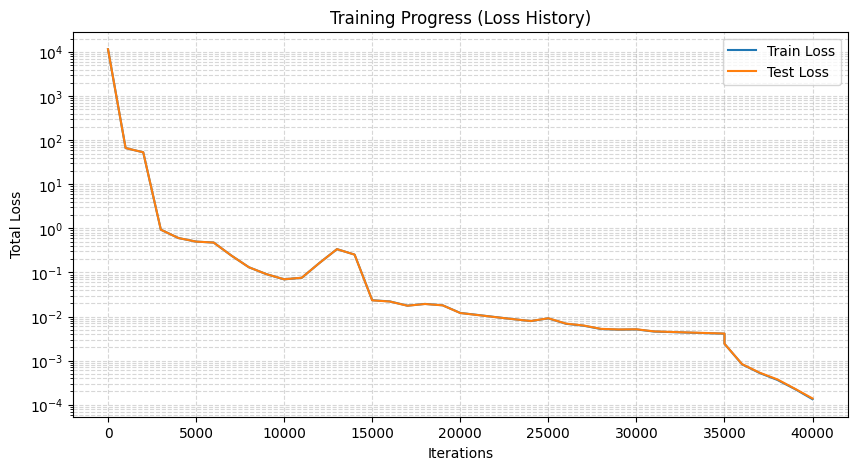

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_loss_history(model_instance):
    loss_history = model_instance.losshistory

    steps = loss_history.steps
    # Summing up losses for all components
    loss_train = np.sum(loss_history.loss_train, axis=1)
    loss_test = np.sum(loss_history.loss_test, axis=1)

    plt.figure(figsize=(10, 5))
    plt.semilogy(steps, loss_train, label="Train Loss")
    plt.semilogy(steps, loss_test, label="Test Loss")
    plt.xlabel("Iterations")
    plt.ylabel("Total Loss")
    plt.title("Training Progress (Loss History)")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.show()

plot_loss_history(model)

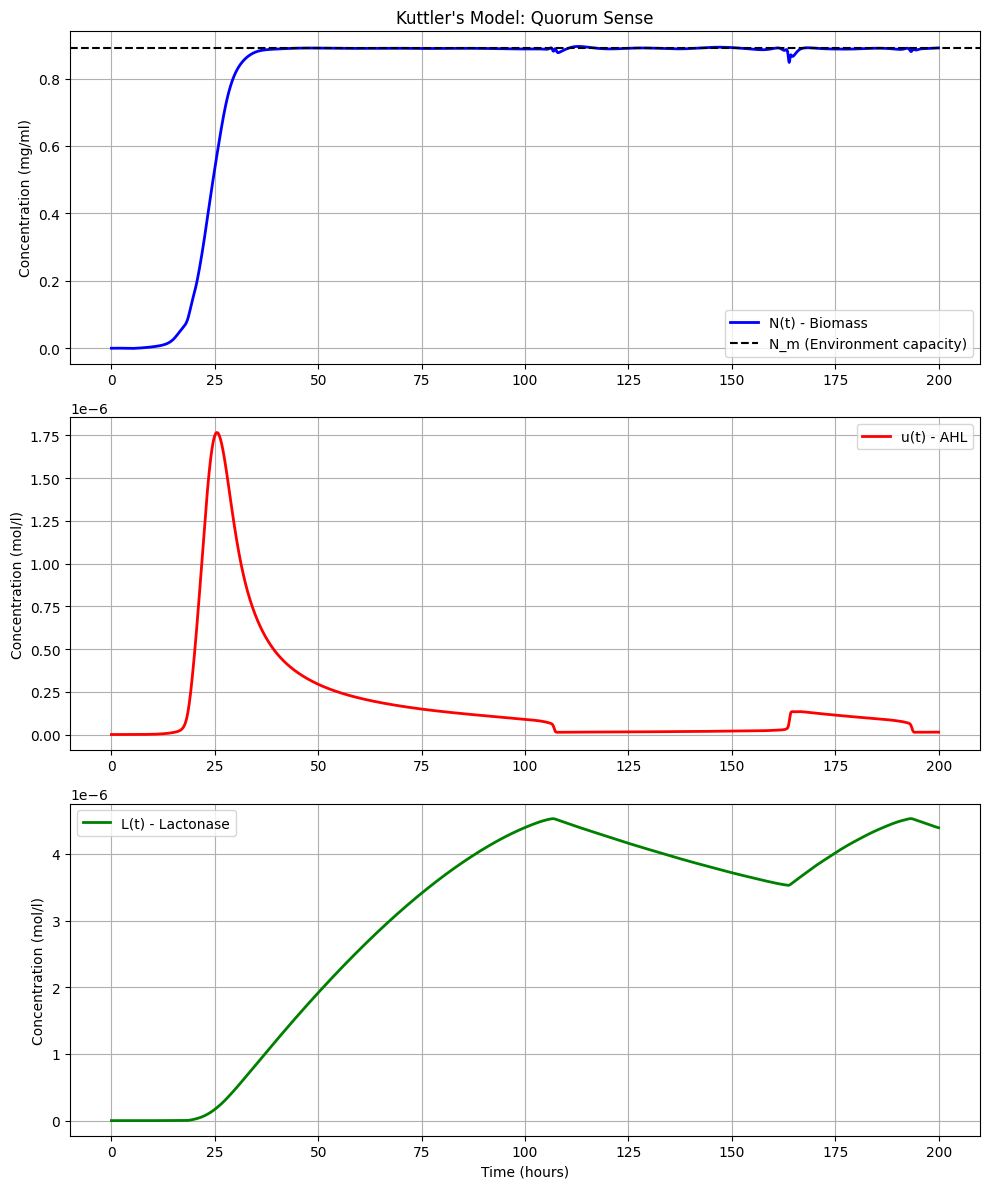

In [8]:
# Visuals
t_test = np.linspace(0, 200, 2000).reshape(-1, 1)
y_pred = model.predict(t_test)

N_pred = np.abs(y_pred[:, 0])
u_pred = np.abs(y_pred[:, 1]) * scale_factor
L_pred = np.abs(y_pred[:, 2]) * scale_factor

plt.figure(figsize=(10, 12))

plt.subplot(3, 1, 1)
plt.plot(t_test, N_pred, label='N(t) - Biomass', color='blue', lw=2)
plt.axhline(y=Nm, color='k', linestyle='--', label='N_m (Environment capacity)')
plt.ylabel('Concentration (mg/ml)')
plt.title('Kuttler\'s Model: Quorum Sense')
plt.grid(True); plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_test, u_pred, label='u(t) - AHL', color='red', lw=2)
plt.ylabel('Concentration (mol/l)')
plt.grid(True); plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_test, L_pred, label='L(t) - Lactonase', color='green', lw=2)
plt.xlabel('Time (hours)')
plt.ylabel('Concentration (mol/l)')
plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import r2_score

# 1. Getting true and predicted values
t_eval = np.linspace(0, 200, 2000).reshape(-1, 1)
y_pred = model.predict(t_eval)
y_true = reference_solution(t_eval)

# 2. Computing metrics for each parameter
components = ['N (Biomss)', 'U (AHL)', 'V (Lactonase)']

print("Model performance assessment\n")

for i, name in enumerate(components):
    # R^2 Score
    r2 = r2_score(y_true[:, i], y_pred[:, i])

    # Relative L2 error: ||y_true - y_pred||_2 / ||y_true||_2
    l2_error = np.linalg.norm(y_true[:, i] - y_pred[:, i]) / np.linalg.norm(y_true[:, i])

    # MSE (Mean Squared Error)
    mse = np.mean((y_true[:, i] - y_pred[:, i])**2)

    print(f"{name}:")
    print(f"  R^2 Score:          {r2:.5f}")
    print(f"  Relative L2 Error: {l2_error:.5e}")
    print(f"  MSE:               {mse:.5e}\n")

# Total L2
total_l2 = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)
print(f"Total L2 error with respect to all variables: {total_l2:.5e}")

Model performance assessment

N (Biomss):
  R^2 Score:          0.99983
  Relative L2 Error: 4.19813e-03
  MSE:               1.21107e-05

U (AHL):
  R^2 Score:          0.99998
  Relative L2 Error: 4.21456e-03
  MSE:               2.58521e-04

V (Lactonase):
  R^2 Score:          1.00000
  Relative L2 Error: 1.46609e-04
  MSE:               2.46555e-05

Total L2 error with respect to all variables: 5.04034e-04
